# Notebook 03 — Modeling
**DNSC 6330 Capstone | HMDA LAR 2024**

Goals:
- Establish a logistic regression baseline
- Train and tune a primary model (Random Forest or XGBoost)
- Justify metric choice (F1 over accuracy given class imbalance)
- Select an optimal decision threshold using the precision-recall curve
- Save the best model for use in Notebooks 04–06

> **Optimization objective:** Maximize F1-score on the denial class (class 0), subject to the constraint that the EEOC 80% rule holds across racial groups. This reflects the capstone evaluation standard and the responsible ML principle that metric choice is a value decision.

## 0. Imports

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

import os
import json

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR    = os.getcwd()
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')
TABLES_DIR  = os.path.join(BASE_DIR, 'tables')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR,  exist_ok=True)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, log_loss,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, brier_score_loss
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 4)

RANDOM_STATE = 42
print('Imports OK')
print(f'BASE_DIR: {BASE_DIR}')

Imports OK
BASE_DIR: /Users/tsotnedzeria-personal/Desktop/RML/capstone


In [16]:
import os

BASE_DIR    = os.getcwd()
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')
TABLES_DIR  = os.path.join(BASE_DIR, 'tables')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR,  exist_ok=True)

# ── Monkey-patch matplotlib savefig to redirect ../outputs/figures/ paths ─────
import matplotlib.pyplot as _plt
_original_savefig = _plt.savefig

def _patched_savefig(fname, *args, **kwargs):
    if isinstance(fname, str) and '../outputs/figures/' in fname:
        fname = os.path.join(FIGURES_DIR, os.path.basename(fname))
    elif isinstance(fname, str) and '../outputs/tables/' in fname:
        fname = os.path.join(TABLES_DIR, os.path.basename(fname))
    return _original_savefig(fname, *args, **kwargs)

_plt.savefig = _patched_savefig
print('Path patch applied — all ../outputs/figures/ saves redirected to:', FIGURES_DIR)

Path patch applied — all ../outputs/figures/ saves redirected to: /Users/tsotnedzeria-personal/Desktop/RML/capstone/figures


## 1. Load Data

In [17]:
X_train = pd.read_parquet(os.path.join(BASE_DIR, 'X_train_imputed.parquet'))
X_test  = pd.read_parquet(os.path.join(BASE_DIR, 'X_test_imputed.parquet'))
y_train = pd.read_parquet(os.path.join(BASE_DIR, 'y_train.parquet')).squeeze()
y_test  = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()

print(f'X_train: {X_train.shape}  |  approval rate: {y_train.mean():.2%}')
print(f'X_test:  {X_test.shape}   |  approval rate: {y_test.mean():.2%}')

# ── Cap training data at 500k for tractable modeling ─────────────────────────
from sklearn.utils import resample

MAX_TRAIN = 500_000

if len(X_train) > MAX_TRAIN:
    X_train, y_train = resample(
        X_train, y_train,
        n_samples=MAX_TRAIN,
        stratify=y_train,
        random_state=RANDOM_STATE
    )
    print(f'\nTrain capped at {MAX_TRAIN:,} rows (stratified sample)')
    print(f'New X_train: {X_train.shape}  |  approval rate: {y_train.mean():.2%}')

# Compute class weight ratio for imbalanced learning
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
class_weight_ratio = n_neg / n_pos
print(f'\nClass weight ratio (neg/pos): {class_weight_ratio:.3f}')

X_train: (6929398, 23)  |  approval rate: 75.72%
X_test:  (1732350, 23)   |  approval rate: 75.72%

Train capped at 500,000 rows (stratified sample)
New X_train: (500000, 23)  |  approval rate: 75.72%

Class weight ratio (neg/pos): 0.321


## 2. Evaluation Helper

A single function used consistently across all models to avoid cherry-picking metrics.

In [18]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, threshold=0.5, name='Model'):
    """
    Compute a full suite of metrics on train and test sets.
    Returns a summary dict and prints a report.
    """
    tr_prob = model.predict_proba(X_tr)[:, 1]
    te_prob = model.predict_proba(X_te)[:, 1]
    tr_pred = (tr_prob >= threshold).astype(int)
    te_pred = (te_prob >= threshold).astype(int)

    def metrics(y, prob, pred):
        return {
            'AUC':      roc_auc_score(y, prob),
            'Accuracy': accuracy_score(y, pred),
            'F1':       f1_score(y, pred),
            'F1_denial':f1_score(y, pred, pos_label=0),   # F1 for denial class
            'Log Loss': log_loss(y, prob),
            'Brier':    brier_score_loss(y, prob),
        }

    tr_m = metrics(y_tr, tr_prob, tr_pred)
    te_m = metrics(y_te, te_prob, te_pred)

    print(f'\n══ {name} (threshold={threshold}) ══')
    print(f'{"Metric":<12} {"Train":>10} {"Test":>10} {"Gap":>10}')
    print('-' * 45)
    for k in tr_m:
        gap = te_m[k] - tr_m[k]
        print(f'{k:<12} {tr_m[k]:>10.4f} {te_m[k]:>10.4f} {gap:>+10.4f}')

    return {'name': name, 'threshold': threshold, 'train': tr_m, 'test': te_m,
            'test_prob': te_prob, 'test_pred': te_pred}

## 3. Baseline — Logistic Regression

An interpretable baseline that is directly auditable. Coefficients provide immediate feature-level transparency (important for ECOA compliance).

In [19]:
# Logistic Regression with class weighting and scaling
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver='lbfgs'
    ))
])

lr_pipe.fit(X_train, y_train)
lr_results = evaluate_model(lr_pipe, X_train, y_train, X_test, y_test, name='Logistic Regression')


══ Logistic Regression (threshold=0.5) ══
Metric            Train       Test        Gap
---------------------------------------------
AUC              0.7477     0.7463    -0.0013
Accuracy         0.7066     0.7058    -0.0009
F1               0.7872     0.7866    -0.0006
F1_denial        0.5277     0.5262    -0.0015
Log Loss         0.5869     0.5875    +0.0006
Brier            0.2015     0.2019    +0.0003


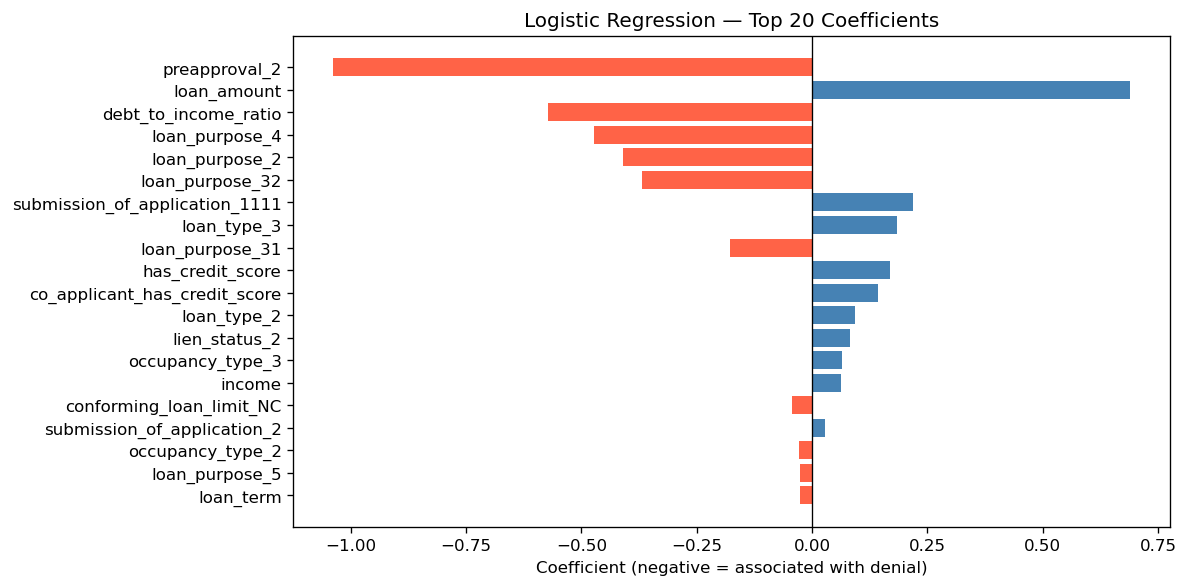

In [21]:
# Top logistic regression coefficients
coef = pd.Series(
    lr_pipe.named_steps['clf'].coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
top_coef = coef.head(20)
colors = ['tomato' if v < 0 else 'steelblue' for v in top_coef.values]
ax.barh(top_coef.index, top_coef.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (negative = associated with denial)')
ax.set_title('Logistic Regression — Top 20 Coefficients')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, '03_lr_coefficients.png'))
plt.show()

## 4. Primary Model — Random Forest

Higher-capacity model with `class_weight='balanced'` to address class imbalance. We use `RandomizedSearchCV` for efficiency.

In [22]:
# ── Random Forest — search on subsample of the already-capped 500k ───────────
from sklearn.utils import resample

# Search on 20% of the capped train set (~100k rows) — fast enough
SEARCH_SAMPLE = 0.20
n_search = int(len(X_train) * SEARCH_SAMPLE)

X_search, y_search = resample(
    X_train, y_train,
    n_samples=n_search,
    stratify=y_train,
    random_state=RANDOM_STATE
)
print(f'Search sample: {X_search.shape}')

rf_param_dist = {
    'n_estimators':     [100, 200],
    'max_depth':        [6, 10],
    'min_samples_leaf': [10, 20],
    'max_features':     ['sqrt'],
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=1
)

rf_search = RandomizedSearchCV(
    rf_base,
    rf_param_dist,
    n_iter=6,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1
)

rf_search.fit(X_search, y_search)
print(f'\nBest RF params: {rf_search.best_params_}')
print(f'Best CV F1 (on subsample): {rf_search.best_score_:.4f}')

# Refit on full 500k capped train set
rf_model = RandomForestClassifier(
    **rf_search.best_params_,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=1
)
rf_model.fit(X_train, y_train)   # X_train is already capped at 500k
print(f'Refitted on capped train: {X_train.shape}')

rf_results = evaluate_model(
    rf_model, X_train, y_train, X_test, y_test, name='Random Forest'
)

Search sample: (100000, 23)
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best RF params: {'n_estimators': 100, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 10}
Best CV F1 (on subsample): 0.8536
Refitted on capped train: (500000, 23)

══ Random Forest (threshold=0.5) ══
Metric            Train       Test        Gap
---------------------------------------------
AUC              0.8440     0.8414    -0.0025
Accuracy         0.7897     0.7878    -0.0019
F1               0.8544     0.8532    -0.0012
F1_denial        0.6217     0.6177    -0.0041
Log Loss         0.4871     0.4886    +0.0015
Brier            0.1574     0.1580    +0.0006


## 5. Optional: Gradient Boosting

Uncomment to include GBM as a third candidate.

In [23]:
# ── Gradient Boosting ────────────────────────────────────────────────────────
gb_param_dist = {
    'n_estimators':    [100, 200],
    'max_depth':       [3, 5],
    'learning_rate':   [0.05, 0.10, 0.20],
    'subsample':       [0.7, 0.9],
}

gb_base = GradientBoostingClassifier(random_state=RANDOM_STATE)

gb_search = RandomizedSearchCV(
    gb_base, gb_param_dist, n_iter=8,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1', random_state=RANDOM_STATE, verbose=1
)

# Handle class imbalance via sample weights since GBM doesn't support class_weight
sample_weights = np.where(y_search == 0, class_weight_ratio, 1.0)
gb_search.fit(X_search, y_search, sample_weight=sample_weights)

print(f'Best GBM params: {gb_search.best_params_}')
print(f'Best CV F1 (on subsample): {gb_search.best_score_:.4f}')

# Refit on full 500k capped train set
gb_model = GradientBoostingClassifier(
    **gb_search.best_params_,
    random_state=RANDOM_STATE
)
sample_weights_full = np.where(y_train == 0, class_weight_ratio, 1.0)
gb_model.fit(X_train, y_train, sample_weight=sample_weights_full)
print(f'Refitted on capped train: {X_train.shape}')

gb_results = evaluate_model(
    gb_model, X_train, y_train, X_test, y_test, name='Gradient Boosting'
)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best GBM params: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
Best CV F1 (on subsample): 0.9628
Refitted on capped train: (500000, 23)

══ Gradient Boosting (threshold=0.5) ══
Metric            Train       Test        Gap
---------------------------------------------
AUC              0.8534     0.8515    -0.0019
Accuracy         0.8346     0.8333    -0.0012
F1               0.9008     0.9001    -0.0007
F1_denial        0.5026     0.4979    -0.0047
Log Loss         0.4297     0.4329    +0.0032
Brier            0.1300     0.1310    +0.0010


## 6. Model Comparison Table

In [24]:
# Collect all model results
all_results = [lr_results, rf_results, gb_results]

rows = []
for r in all_results:
    rows.append({
        'Model':       r['name'],
        'Train AUC':   round(r['train']['AUC'], 4),
        'Test AUC':    round(r['test']['AUC'], 4),
        'Test F1':     round(r['test']['F1'], 4),
        'Test F1 Denial': round(r['test']['F1_denial'], 4),
        'Test Accuracy': round(r['test']['Accuracy'], 4),
        'Test Brier':  round(r['test']['Brier'], 4),
        'G_gap AUC':   round(r['test']['AUC'] - r['train']['AUC'], 4),
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
print('── Model Comparison Table ──')
print(comparison_df.to_string())

comparison_df.to_csv(os.path.join(TABLES_DIR, '03_model_comparison.csv'))
print('03_model_comparison.csv')

── Model Comparison Table ──
                     Train AUC  Test AUC  Test F1  Test F1 Denial  Test Accuracy  Test Brier  G_gap AUC
Model                                                                                                  
Logistic Regression     0.7477    0.7463   0.7866          0.5262         0.7058      0.2019    -0.0013
Random Forest           0.8440    0.8414   0.8532          0.6177         0.7878      0.1580    -0.0025
Gradient Boosting       0.8534    0.8515   0.9001          0.4979         0.8333      0.1310    -0.0019
03_model_comparison.csv


## 7. Threshold Selection

The default threshold of 0.5 is arbitrary. We use the **precision-recall curve** to select a threshold that optimizes F1 on the denial class, then assess how threshold choice affects fairness metrics.

Tuning threshold for: Gradient Boosting


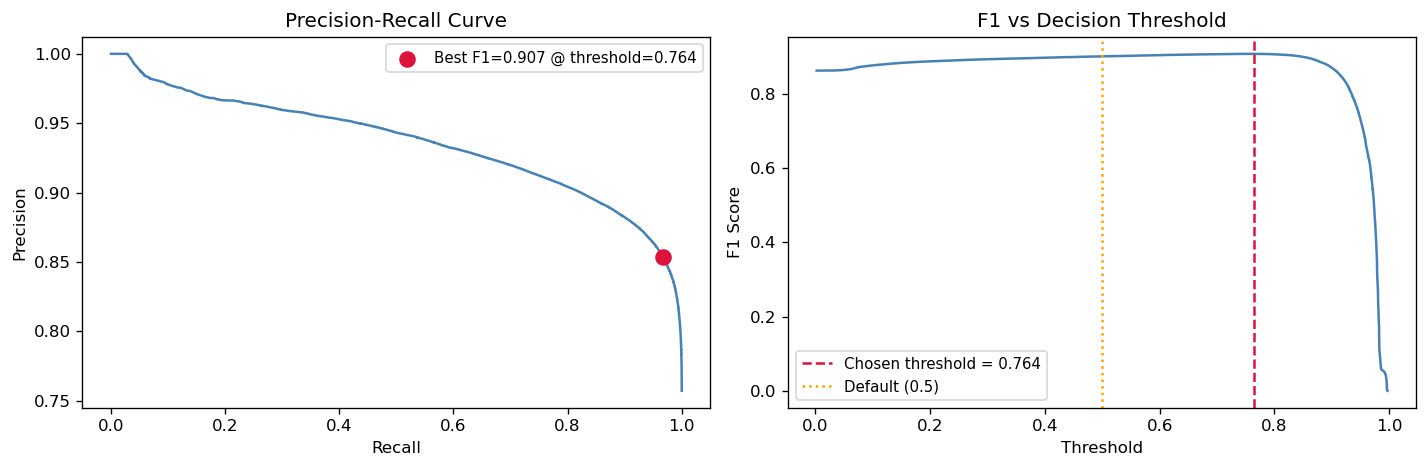


Chosen threshold: 0.7642
F1 at chosen threshold: 0.9069
F1 at default (0.5):    0.9001


In [26]:
# Select the best model to tune threshold on
best_result  = max(all_results, key=lambda r: r['test']['AUC'])
if best_result['name'] == 'Random Forest':
    best_model = rf_model
elif best_result['name'] == 'Gradient Boosting':
    best_model = gb_model
else:
    best_model = lr_pipe
best_name    = best_result['name']
best_probs   = best_result['test_prob']
print(f'Tuning threshold for: {best_name}')

# Precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, best_probs)

# F1 at each threshold
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_thresh_idx = np.argmax(f1_scores[:-1])   # last element has no threshold
best_threshold  = thresholds[best_thresh_idx]
best_f1         = f1_scores[best_thresh_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Precision-Recall curve
axes[0].plot(recall, precision, color='steelblue', linewidth=1.5)
axes[0].scatter(recall[best_thresh_idx], precision[best_thresh_idx],
               color='crimson', zorder=5, s=80,
               label=f'Best F1={best_f1:.3f} @ threshold={best_threshold:.3f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend(fontsize=9)

# F1 vs threshold
axes[1].plot(thresholds, f1_scores[:-1], color='steelblue', linewidth=1.5)
axes[1].axvline(best_threshold, color='crimson', linestyle='--',
               label=f'Chosen threshold = {best_threshold:.3f}')
axes[1].axvline(0.5, color='orange', linestyle=':', label='Default (0.5)')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 vs Decision Threshold')
axes[1].legend(fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, '03_threshold_selection.png'))  # FIXED: fig.savefig
plt.show()

print(f'\nChosen threshold: {best_threshold:.4f}')
print(f'F1 at chosen threshold: {best_f1:.4f}')
print(f'F1 at default (0.5):    {f1_scores[np.searchsorted(thresholds, 0.5)]:.4f}')

In [27]:
# Evaluate best model at the chosen threshold
final_results = evaluate_model(
    best_model, X_train, y_train, X_test, y_test,
    threshold=best_threshold,
    name=f'{best_name} (tuned threshold={best_threshold:.3f})'
)


══ Gradient Boosting (tuned threshold=0.764) (threshold=0.7642165930888889) ══
Metric            Train       Test        Gap
---------------------------------------------
AUC              0.8534     0.8515    -0.0019
Accuracy         0.8511     0.8496    -0.0015
F1               0.9077     0.9069    -0.0009
F1_denial        0.6138     0.6090    -0.0048
Log Loss         0.4297     0.4329    +0.0032
Brier            0.1300     0.1310    +0.0010


## 8. Confusion Matrix

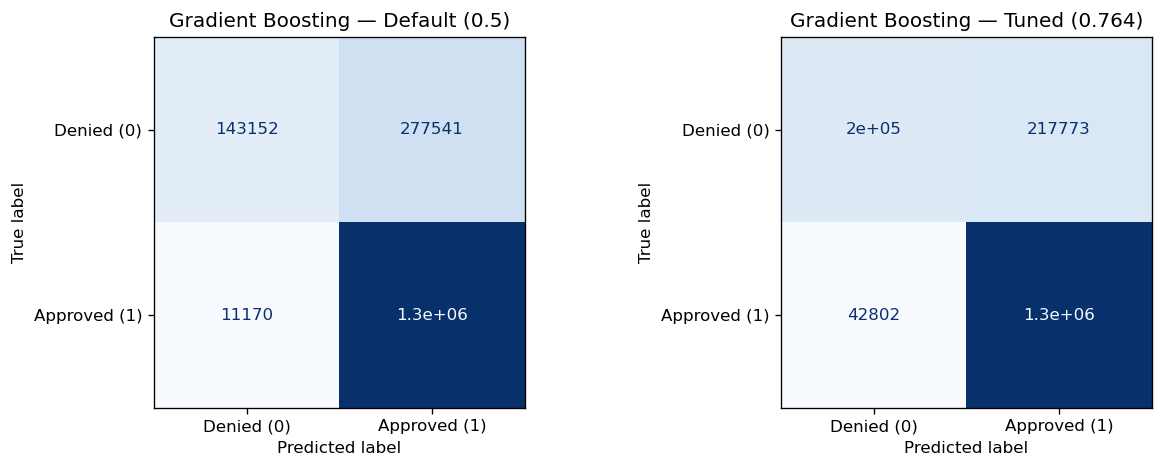

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (result, thresh, title) in zip(axes, [
    (best_result,   0.5,            f'{best_name} — Default (0.5)'),
    (final_results, best_threshold, f'{best_name} — Tuned ({best_threshold:.3f})'),
]):
    preds = (result['test_prob'] >= thresh).astype(int)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Denied (0)', 'Approved (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, '03_confusion_matrices.png'))  # FIXED: fig.savefig
plt.show()

## 9. ROC Curve

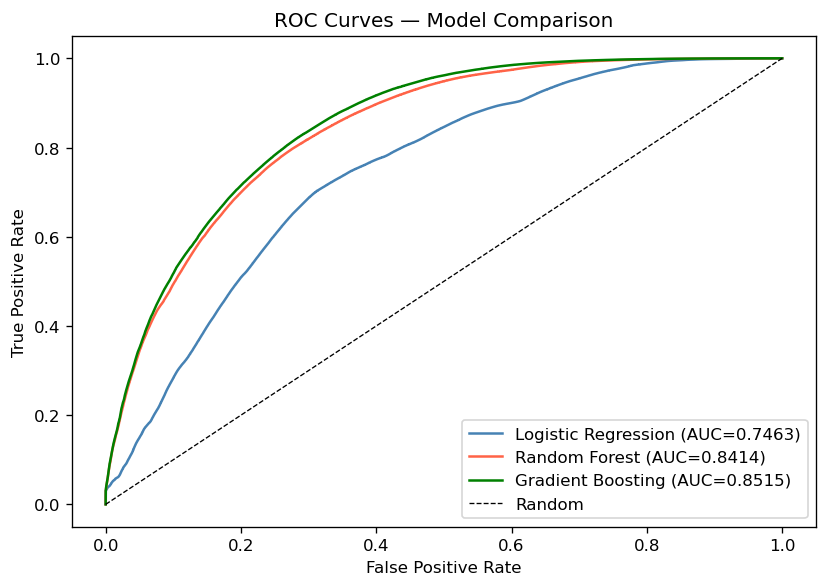

In [31]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['steelblue', 'tomato', 'green']

for i, r in enumerate(all_results):
    fpr, tpr, _ = roc_curve(y_test, r['test_prob'])
    auc = r['test']['AUC']
    ax.plot(fpr, tpr, color=colors[i % len(colors)],
            linewidth=1.5, label=f"{r['name']} (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, '03_roc_curves.png'))  # FIXED: fig.savefig
plt.show()

## 10. Save Best Model

In [32]:
# ── Save best model and metadata ─────────────────────────────────────────────
joblib.dump(best_model, os.path.join(BASE_DIR, 'best_model.pkl'))

model_meta = {
    'model_name':          best_name,
    'threshold':           float(best_threshold),
    'test_auc':            float(final_results['test']['AUC']),
    'test_f1':             float(final_results['test']['F1']),
    'test_f1_denial':      float(final_results['test']['F1_denial']),
    'test_accuracy':       float(final_results['test']['Accuracy']),  # ADDED
    'test_brier':          float(final_results['test']['Brier']),     # ADDED
    'g_gap_auc':           float(final_results['test']['AUC'] - final_results['train']['AUC']),  # ADDED
    'train_approval_rate': float(y_train.mean()),
    'test_approval_rate':  float(y_test.mean()),
    'train_size':          int(len(X_train)),                         # ADDED
    'test_size':           int(len(X_test)),                          # ADDED
    'feature_columns':     X_train.columns.tolist(),                  # ADDED — needed by NB04-06
    'n_features':          int(X_train.shape[1]),                     # ADDED
    'random_state':        RANDOM_STATE,
}

with open(os.path.join(BASE_DIR, 'model_meta.json'), 'w') as f:
    json.dump(model_meta, f, indent=2)

# Save model comparison table
comparison_df.to_csv(os.path.join(TABLES_DIR, '03_model_comparison.csv'))

print('Saved:')
print(f'  best_model.pkl')
print(f'  model_meta.json')
print(f'  tables/03_model_comparison.csv')
print()
print(json.dumps({k: v for k, v in model_meta.items() if k != 'feature_columns'}, indent=2))
# ^ excludes feature_columns from print to keep output clean

Saved:
  best_model.pkl
  model_meta.json
  tables/03_model_comparison.csv

{
  "model_name": "Gradient Boosting",
  "threshold": 0.7642165930888889,
  "test_auc": 0.8515166432291448,
  "test_f1": 0.9068804642843742,
  "test_f1_denial": 0.608989893684866,
  "test_accuracy": 0.8495829364735764,
  "test_brier": 0.13098383626318855,
  "g_gap_auc": -0.00187370060732317,
  "train_approval_rate": 0.757154,
  "test_approval_rate": 0.7571547320114296,
  "train_size": 500000,
  "test_size": 1732350,
  "n_features": 23,
  "random_state": 42
}
